# **Problem 1: Simulating Customer Clicks Using a Bernoulli Random Variable**

## Problem Statement

An organization sends promotional emails. Historical data indicate that a customer clicks the link with probability:

\[
p = 0.30
\]

We will model customer clicks using a Bernoulli random variable, simulate 20 customers, calculate the empirical PMF, compare it with the theoretical PMF, calculate expectation and variance, and study the effect of sample size.

> **Note:** The observations generated by this notebook are random, so the empirical values can change every time the notebook is run.

## 1. Import Required Libraries

We use:

- **NumPy** for random simulation and numerical calculations.
- **Matplotlib** for plotting the theoretical and empirical PMFs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Given Values

The probability that a customer clicks the promotional link is:

\[
p = 0.30
\]

For the first experiment, we generate observations for:

\[
n = 20
\]

customers.

In [2]:
p = 0.30
sample_size = 20

print("Probability of click:", p)
print("Sample size:", sample_size)

Probability of click: 0.3
Sample size: 20


## 3. Step 1 — Identify the Random Variable

Define:

\[
X =
\begin{cases}
1 & \text{if the customer clicks the link} \\
0 & \text{if the customer does not click the link}
\end{cases}
\]

### Answers

**What does \(X=1\) represent?**

A customer clicks the promotional email link.

**What does \(X=0\) represent?**

A customer does not click the promotional email link.

**What are the possible values of \(X\)?**

\[
X \in \{0,1\}
\]

**Is \(X\) discrete or continuous?**

\(X\) is a **discrete random variable** because it can take only the values 0 and 1.

**Which probability distribution is suitable for \(X\)?**

The **Bernoulli distribution**, because there is one trial with two possible outcomes: click or no click.

## 4. Step 2 — Theoretical PMF

For a Bernoulli random variable:

\[
P(X=x)=p^x(1-p)^{1-x}
\]

Given:

\[
p=0.30
\]

Therefore:

\[
P(X=0)=1-p=0.70
\]

\[
P(X=1)=p=0.30
\]

| X | Meaning | Theoretical Probability |
|---|---|---:|
| 0 | No click | 0.70 |
| 1 | Click | 0.30 |

In [3]:
theoretical_p_0 = 1 - p
theoretical_p_1 = p

print("Theoretical P(X=0):", theoretical_p_0)
print("Theoretical P(X=1):", theoretical_p_1)
print("Sum of probabilities:", theoretical_p_0 + theoretical_p_1)

Theoretical P(X=0): 0.7
Theoretical P(X=1): 0.3
Sum of probabilities: 1.0


## 5. Step 3 — Generate Outcomes for 20 Customers

The problem specifies using:

```python
np.random.binomial(n=1, p=p, size=sample_size)
```

Because `n=1`, each generated observation is a Bernoulli observation.

- `0` → customer did not click
- `1` → customer clicked

In [4]:
samples = np.random.binomial(
    n=1,
    p=p,
    size=sample_size
)

print("Generated observations:")
print(samples)
print("\nNumber of observations:", len(samples))

Generated observations:
[0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 1 1 1 0 0]

Number of observations: 20


### Answers

**How many observations were generated?**

20 observations.

**What does each zero represent?**

A customer did not click.

**What does each one represent?**

A customer clicked.

**Are the generated observations the same as the theoretical probabilities?**

Not necessarily. The theoretical click probability is 0.30, but the empirical probability from only 20 randomly generated observations can be different because of random variation.

## 6. Step 4 — Count Clicks and Non-Clicks

Since:

- `1` represents a click
- `0` represents a non-click

we count them using NumPy.

In [5]:
number_of_clicks = np.sum(samples == 1)
number_of_non_clicks = np.sum(samples == 0)

print("Number of clicks:", number_of_clicks)
print("Number of non-clicks:", number_of_non_clicks)
print("Total:", number_of_clicks + number_of_non_clicks)

Number of clicks: 7
Number of non-clicks: 13
Total: 20


### Answers

**How many customers clicked?**

The value of `number_of_clicks` from the generated sample.

**How many customers did not click?**

The value of `number_of_non_clicks` from the generated sample.

**Do the two counts add up to 20?**

Yes.

\[
\text{clicks} + \text{non-clicks} = 20
\]

The exact two counts change when the random simulation is run again.

## 7. Step 5 — Calculate the Empirical PMF

The empirical probability is calculated from the generated observations.

In [6]:
empirical_p_0 = number_of_non_clicks / sample_size
empirical_p_1 = number_of_clicks / sample_size

print("Empirical P(X=0):", empirical_p_0)
print("Empirical P(X=1):", empirical_p_1)
print("Sum of empirical probabilities:", empirical_p_0 + empirical_p_1)

Empirical P(X=0): 0.65
Empirical P(X=1): 0.35
Sum of empirical probabilities: 1.0


## 8. Step 6 — Compare Empirical and Theoretical PMFs

The theoretical PMF is fixed:

\[
P(X=0)=0.70
\]

\[
P(X=1)=0.30
\]

The empirical PMF depends on the randomly generated sample.

#### Answers

**Is the empirical probability of a click exactly 0.30?**

Not necessarily. It depends on the generated observations.

**Which outcome has the larger theoretical probability?**

No click, \(X=0\), because:

\[
0.70 > 0.30
\]

**Why are empirical and theoretical probabilities different?**

The theoretical probability represents the model probability, while the empirical probability is calculated from a finite random sample. Random variation can make the two values different.

In [7]:
print("Comparison of PMFs")
print("-" * 45)
print(f"{'X':<10}{'Theoretical':<15}{'Empirical':<15}")
print("-" * 45)
print(f"{0:<10}{theoretical_p_0:<15.4f}{empirical_p_0:<15.4f}")
print(f"{1:<10}{theoretical_p_1:<15.4f}{empirical_p_1:<15.4f}")

Comparison of PMFs
---------------------------------------------
X         Theoretical    Empirical      
---------------------------------------------
0         0.7000         0.6500         
1         0.3000         0.3500         


## 9. Step 7 — Plot Empirical and Theoretical PMFs

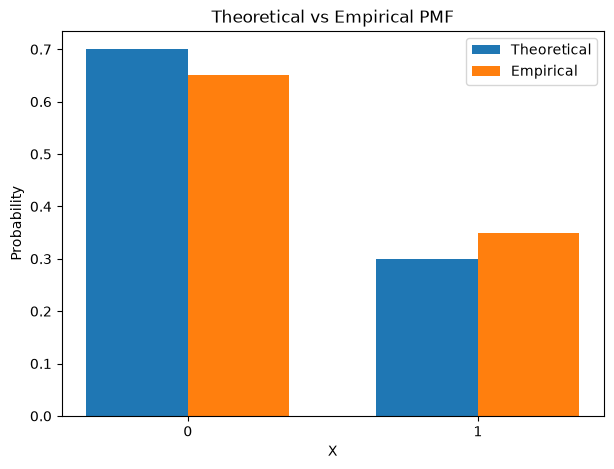

In [8]:
x = np.array([0, 1])

theoretical_pmf = np.array([
    theoretical_p_0,
    theoretical_p_1
])

empirical_pmf = np.array([
    empirical_p_0,
    empirical_p_1
])

width = 0.35

plt.figure(figsize=(7, 5))

plt.bar(
    x - width / 2,
    theoretical_pmf,
    width=width,
    label="Theoretical"
)

plt.bar(
    x + width / 2,
    empirical_pmf,
    width=width,
    label="Empirical"
)

plt.xlabel("X")
plt.ylabel("Probability")
plt.title("Theoretical vs Empirical PMF")
plt.xticks(x)
plt.legend()
plt.show()

## 10. Step 8 — Calculate Theoretical Expectation

For a Bernoulli random variable:

\[
E[X]=p
\]

Given:

\[
p=0.30
\]

Therefore:

\[
\boxed{E[X]=0.30}
\]

In [9]:
theoretical_mean = p

print("Theoretical expectation:", theoretical_mean)

Theoretical expectation: 0.3


## 11. Step 9 — Calculate Empirical Expectation

The empirical expectation is the sample mean:

\[
\bar X = \frac{1}{n}\sum_{i=1}^{n}X_i
\]

Since the observations are only 0 and 1, the empirical mean is also the observed proportion of clicks.

In [10]:
empirical_mean = np.mean(samples)

print("Empirical expectation:", empirical_mean)

Empirical expectation: 0.35


## 12. Step 10 — Calculate Theoretical Variance

For a Bernoulli random variable:

\[
Var(X)=p(1-p)
\]

Therefore:

\[
Var(X)=0.30(1-0.30)
\]

\[
=0.30(0.70)
\]

\[
\boxed{Var(X)=0.21}
\]

In [11]:
theoretical_variance = p * (1 - p)

print("Theoretical variance:", theoretical_variance)

Theoretical variance: 0.21


## 13. Step 11 — Calculate Empirical Variance

The empirical variance is calculated from the generated observations using NumPy.

In [12]:
empirical_variance = np.var(samples)

print("Empirical variance:", empirical_variance)

Empirical variance: 0.22749999999999995


## 14. Step 12 — Final Result Table

The absolute difference is:

\[
|\text{Theoretical} - \text{Empirical}|
\]

We compare expectation and variance.

In [13]:
mean_difference = abs(
    theoretical_mean - empirical_mean
)

variance_difference = abs(
    theoretical_variance - empirical_variance
)

print("Final Result Table")
print("-" * 65)
print(
    f"{'Measure':<20}"
    f"{'Theoretical':<15}"
    f"{'Empirical':<15}"
    f"{'Absolute Difference':<20}"
)
print("-" * 65)

print(
    f"{'Expectation':<20}"
    f"{theoretical_mean:<15.4f}"
    f"{empirical_mean:<15.4f}"
    f"{mean_difference:<20.4f}"
)

print(
    f"{'Variance':<20}"
    f"{theoretical_variance:<15.4f}"
    f"{empirical_variance:<15.4f}"
    f"{variance_difference:<20.4f}"
)

Final Result Table
-----------------------------------------------------------------
Measure             Theoretical    Empirical      Absolute Difference 
-----------------------------------------------------------------
Expectation         0.3000         0.3500         0.0500              
Variance            0.2100         0.2275         0.0175              


## 15. Step 13 — Effect of Sample Size

The experiment is repeated for:

\[
n=10,100,1000,10000
\]

For each sample size, we calculate:

- Empirical \(P(X=0)\)
- Empirical \(P(X=1)\)
- Empirical mean
- Empirical variance

The exact values are random and can change between runs.

In [14]:
sample_sizes = [10, 100, 1000, 10000]

results = []

for n in sample_sizes:
    samples_n = np.random.binomial(
        n=1,
        p=p,
        size=n
    )

    count_0 = np.sum(samples_n == 0)
    count_1 = np.sum(samples_n == 1)

    probability_0 = count_0 / n
    probability_1 = count_1 / n

    mean_n = np.mean(samples_n)
    variance_n = np.var(samples_n)

    results.append([
        n,
        probability_0,
        probability_1,
        mean_n,
        variance_n
    ])

print(
    f"{'Sample Size':<15}"
    f"{'P(X=0)':<15}"
    f"{'P(X=1)':<15}"
    f"{'Mean':<15}"
    f"{'Variance':<15}"
)

print("-" * 75)

for row in results:
    print(
        f"{row[0]:<15}"
        f"{row[1]:<15.4f}"
        f"{row[2]:<15.4f}"
        f"{row[3]:<15.4f}"
        f"{row[4]:<15.4f}"
    )

Sample Size    P(X=0)         P(X=1)         Mean           Variance       
---------------------------------------------------------------------------
10             0.8000         0.2000         0.2000         0.1600         
100            0.6900         0.3100         0.3100         0.2139         
1000           0.6660         0.3340         0.3340         0.2224         
10000          0.7023         0.2977         0.2977         0.2091         


---
#

# **Problem 2: Simulating Fraud Detection Using a Binomial Random Variable**

## Problem Statement

A fraud-detection model examines 50 transactions every hour.
Each transaction has a 4% probability of being flagged.

Assume that the flagging decisions for individual transactions
are independent.

The fraud investigation team can examine at most 4 flagged
transactions per hour.

Simulate the operation for 20,000 independent one-hour periods.

Let X represent the total number of flagged transactions in one hour.

## Step 1: Identify the Random Variable

Let:

X = Number of flagged transactions in one hour.

For every hour:

- Number of transactions = 50
- Probability of a transaction being flagged = 0.04
- Probability of not being flagged = 0.96

Therefore:

X ~ Binomial(n = 50, p = 0.04)

Why Binomial?

Because:

1. There is a fixed number of trials → 50 transactions.
2. Each transaction has two outcomes:
   - Flagged
   - Not flagged
3. Probability of being flagged remains constant → 0.04.
4. The transactions are assumed to be independent.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Given Values

n = 50 transactions per hour

p = 0.04 probability of being flagged

Number of simulated hours = 20,000

Maximum investigation capacity = 4 flagged transactions per hour

In [4]:
# Given parameters

n = 50
p = 0.04
number_of_hours = 20_000
maximum_capacity = 4

print("Transactions per hour:", n)
print("Flagging probability:", p)
print("Number of simulated hours:", number_of_hours)
print("Maximum investigation capacity:", maximum_capacity)

Transactions per hour: 50
Flagging probability: 0.04
Number of simulated hours: 20000
Maximum investigation capacity: 4


## Step 3: Theoretical Distribution

The number of flagged transactions follows a Binomial distribution:

X ~ Binomial(50, 0.04)

The probability mass function is:

P(X = x) = C(n, x) p^x (1-p)^(n-x)

For this problem:

P(X = x) = C(50, x)(0.04)^x(0.96)^(50-x)

## Step 4: Theoretical Expected Number of Flagged Transactions

For a Binomial random variable:

E[X] = np

Therefore:

E[X] = 50 × 0.04
     = 2

So, theoretically, the model is expected to flag:

2 transactions per hour.

In [5]:
theoretical_mean = n * p

print("Theoretical Expected Value:", theoretical_mean)

Theoretical Expected Value: 2.0


## Step 5: Theoretical Variance

For a Binomial random variable:

Var(X) = np(1-p)

Therefore:

Var(X) = 50 × 0.04 × (1 - 0.04)

       = 50 × 0.04 × 0.96

       = 1.92

Therefore:

Theoretical variance = 1.92

In [6]:
theoretical_variance = n * p * (1 - p)

print("Theoretical Variance:", theoretical_variance)

Theoretical Variance: 1.92


## Step 6: Simulate 20,000 Independent One-Hour Periods

For each hour, there are 50 transactions.

Each transaction has a 4% probability of being flagged.

We use NumPy's binomial distribution to simulate this process.

Each generated value represents the total number of flagged
transactions during one hour.

In [7]:
flagged_transactions = np.random.binomial(
    n=n,
    p=p,
    size=number_of_hours
)

print("Simulation completed.")
print("Total simulated hours:", len(flagged_transactions))

Simulation completed.
Total simulated hours: 20000


In [8]:
print("Flagged transactions in the first 20 hours:")

print(flagged_transactions[:20])

Flagged transactions in the first 20 hours:
[4 2 1 0 2 1 3 1 1 2 1 2 1 2 1 2 0 3 3 5]


## Step 7: Understanding the Generated Values

Each value represents the number of flagged transactions
during one hour.

For example:

X = 0 → No transactions were flagged.

X = 1 → One transaction was flagged.

X = 2 → Two transactions were flagged.

X = 4 → Four transactions were flagged.

X = 5 → Five transactions were flagged.

Since the investigation team can examine at most 4 flagged
transactions per hour:

X ≤ 4 → Within investigation capacity

X > 4 → Investigation capacity is exceeded

## Step 8: Empirical Expected Value

The empirical mean is calculated from the 20,000 simulated hours.

Empirical Mean:

X̄ = Sum of all simulated values / Number of simulations

We expect the empirical mean to be close to the theoretical
expected value of 2 as the number of simulations is large.

In [9]:
empirical_mean = np.mean(flagged_transactions)

print("Theoretical Mean:", theoretical_mean)
print("Empirical Mean:", empirical_mean)
print("Difference:", abs(theoretical_mean - empirical_mean))

Theoretical Mean: 2.0
Empirical Mean: 1.98815
Difference: 0.011849999999999916


## Step 9: Empirical Variance

The variance of the 20,000 simulated observations is calculated
using NumPy.

The theoretical variance is:

Var(X) = 1.92

The empirical variance should generally be close to 1.92 because
we have simulated a large number of hours.

In [10]:
empirical_variance = np.var(flagged_transactions)

print("Theoretical Variance:", theoretical_variance)
print("Empirical Variance:", empirical_variance)
print("Difference:", abs(theoretical_variance - empirical_variance))

Theoretical Variance: 1.92
Empirical Variance: 1.9151095775000002
Difference: 0.004890422499999714


## Step 10: Investigation Capacity

The investigation team can examine at most 4 flagged transactions
per hour.

Therefore:

Within capacity:

X ≤ 4

Capacity exceeded:

X > 4

In [11]:
hours_within_capacity = np.sum(flagged_transactions <= maximum_capacity)

print("Hours within capacity:", hours_within_capacity)

Hours within capacity: 19036


In [12]:
hours_exceeding_capacity = np.sum(flagged_transactions > maximum_capacity)

print("Hours exceeding capacity:", hours_exceeding_capacity)

Hours exceeding capacity: 964


## Step 11: Empirical Probability

The empirical probability that the investigation team can handle
all flagged transactions is:

P(X ≤ 4)

The empirical probability that the investigation capacity is
exceeded is:

P(X > 4)

In [13]:
probability_within_capacity = (
    hours_within_capacity / number_of_hours
)

probability_capacity_exceeded = (
    hours_exceeding_capacity / number_of_hours
)

print("Empirical P(X <= 4):", probability_within_capacity)
print("Empirical P(X > 4):", probability_capacity_exceeded)

Empirical P(X <= 4): 0.9518
Empirical P(X > 4): 0.0482


## Step 12: Probability Check

The two possible cases are:

1. X ≤ 4
2. X > 4

Therefore:

P(X ≤ 4) + P(X > 4) = 1

The empirical probabilities should approximately add up to 1.

In [14]:
probability_sum = (
    probability_within_capacity +
    probability_capacity_exceeded
)

print("P(X <= 4) + P(X > 4):", probability_sum)

P(X <= 4) + P(X > 4): 1.0


In [15]:
results = pd.DataFrame({
    "Measure": [
        "Theoretical Mean",
        "Empirical Mean",
        "Theoretical Variance",
        "Empirical Variance",
        "Hours Within Capacity",
        "Hours Exceeding Capacity",
        "P(X <= 4)",
        "P(X > 4)"
    ],
    
    "Value": [
        theoretical_mean,
        empirical_mean,
        theoretical_variance,
        empirical_variance,
        hours_within_capacity,
        hours_exceeding_capacity,
        probability_within_capacity,
        probability_capacity_exceeded
    ]
})

results

,Measure,Value
0,Theoretical Mean,2.00000
1,Empirical Mean,1.98815
2,Theoretical Variance,1.92000
3,Empirical Variance,1.91511
4,Hours Within Capacity,19036.00000
5,Hours Exceeding Capacity,964.00000
6,P(X <= 4),0.95180
7,P(X > 4),0.04820


## Step 13: Plot the Simulated Distribution

The following plot shows how many flagged transactions occurred
across the 20,000 simulated hours.

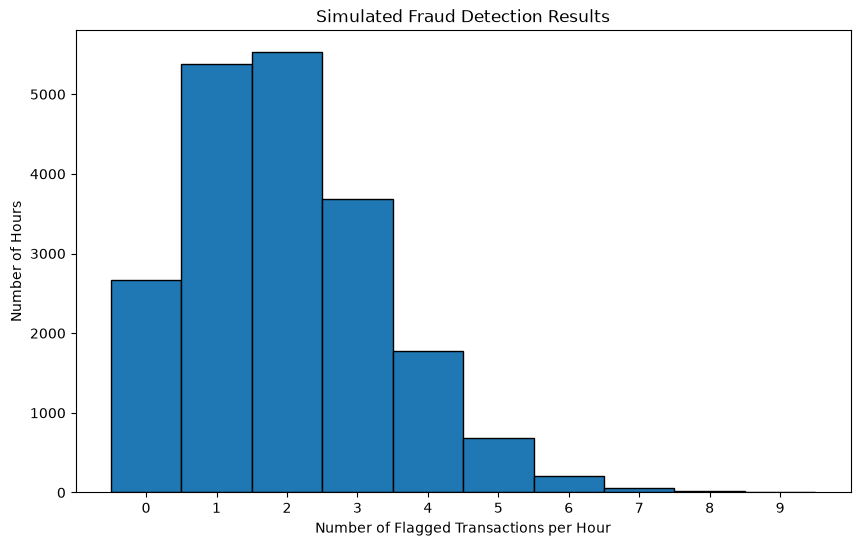

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(
    flagged_transactions,
    bins=np.arange(
        flagged_transactions.min(),
        flagged_transactions.max() + 2
    ) - 0.5,
    edgecolor="black"
)

plt.xlabel("Number of Flagged Transactions per Hour")
plt.ylabel("Number of Hours")
plt.title("Simulated Fraud Detection Results")

plt.xticks(
    range(
        flagged_transactions.min(),
        flagged_transactions.max() + 1
    )
)

plt.show()

## Final Interpretation

The random variable X represents the number of flagged
transactions in one hour.

Since there are 50 transactions per hour, each with a 4%
probability of being flagged, X follows a Binomial distribution:

X ~ Binomial(50, 0.04)

The theoretical expected number of flagged transactions is:

E[X] = 2

The theoretical variance is:

Var(X) = 1.92

The simulation generates 20,000 independent one-hour periods.

The empirical mean and variance should be close to their
theoretical values.

The investigation team can handle at most 4 flagged transactions
per hour.

Therefore:

X ≤ 4 → Team can handle the flagged transactions.

X > 4 → Investigation capacity is exceeded.